In [1]:
# имопрт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
# загрузка данных
df = pd.read_csv("../data/processed/ml_delivery_dataset.csv")
df.head()

,order_id,delivery_time_days,total_price,total_freight,num_items,avg_product_weight_g,avg_product_length_cm,avg_product_height_cm,avg_product_width_cm,avg_product_volume_cm3,purchase_dayofweek,purchase_month,customer_state,seller_state
0,5e605c248def72c23690c44126f8ecb6,14,39.99,15.10,1,350.0,25.0,8.0,19.0,3800.0,1,2,MG,SP
1,c45067032fd84f4cf408730ff5205568,6,179.80,19.14,1,7400.0,45.0,29.0,53.0,69165.0,3,5,PR,SP
2,8013932c4c00036478bea6424e783117,14,44.90,15.10,1,350.0,20.0,2.0,26.0,1040.0,3,2,RS,SP
3,385afce75f62f7af7587814b87692d2d,11,80.00,12.90,1,1600.0,45.0,15.0,30.0,20250.0,4,2,SP,SP
4,cb7c837f8c5240816176dc115c21a746,13,150.00,88.56,1,4000.0,30.0,35.0,30.0,31500.0,4,6,RN,SP


In [3]:
# Размерность
df.shape

(96986, 14)

In [4]:
# быстрый просмотр данных
df.info()
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 96986 entries, 0 to 96985
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                96986 non-null  str    
 1   delivery_time_days      96986 non-null  int64  
 2   total_price             96986 non-null  float64
 3   total_freight           96986 non-null  float64
 4   num_items               96986 non-null  int64  
 5   avg_product_weight_g    96970 non-null  float64
 6   avg_product_length_cm   96970 non-null  float64
 7   avg_product_height_cm   96970 non-null  float64
 8   avg_product_width_cm    96970 non-null  float64
 9   avg_product_volume_cm3  96970 non-null  float64
 10  purchase_dayofweek      96986 non-null  int64  
 11  purchase_month          96986 non-null  int64  
 12  customer_state          96986 non-null  str    
 13  seller_state            96986 non-null  str    
dtypes: float64(7), int64(4), str(3)
memory usage: 10.

,count,mean,std,min,25%,50%,75%,max
delivery_time_days,96986.0,12.477543,9.540919,0.00,7.00,10.00,16.00,210.00
total_price,96986.0,137.534251,209.332743,0.85,45.90,86.99,149.90,13440.00
total_freight,96986.0,22.927710,21.716089,0.00,13.88,17.24,24.35,1794.96
num_items,96986.0,1.149290,0.551549,1.00,1.00,1.00,1.00,21.00
avg_product_weight_g,96970.0,2096.491790,3739.177921,0.00,300.00,700.00,1813.00,40425.00
avg_product_length_cm,96970.0,30.082882,16.031457,7.00,18.00,25.00,38.00,105.00
avg_product_height_cm,96970.0,16.440569,13.224290,2.00,8.00,13.00,20.00,105.00
avg_product_width_cm,96970.0,23.005282,11.670678,6.00,15.00,20.00,30.00,118.00
avg_product_volume_cm3,96970.0,15139.995987,23178.907755,168.00,2816.00,6400.00,18150.00,296208.00
purchase_dayofweek,96986.0,2.912431,1.895239,0.00,1.00,3.00,5.00,6.00


Пропусков нет, и все признаки рассчитаны корректно.
Распределение времени доставки имеет медиану около 10 дней, но наблюдается длинный хвост до 210 дней, что предварительно указывает на наличие выбросов.
Кроме того, по цене, стоимости доставки и объёму товара заметны аномально большие значения, которые также следует учитывать при моделировании.

In [5]:
# проверка пропусков
df.isna().sum()

order_id                   0
delivery_time_days         0
total_price                0
total_freight              0
num_items                  0
avg_product_weight_g      16
avg_product_length_cm     16
avg_product_height_cm     16
avg_product_width_cm      16
avg_product_volume_cm3    16
purchase_dayofweek         0
purchase_month             0
customer_state             0
seller_state               0
dtype: int64

Пропусков в основных признаках нет.
Однако в характеристиках товара (вес, длина, высота, ширина, объём) присутствует 16 пропусков. В Olist есть некоторые товары, у которых отсутствуют данные о размерах или весе в таблице products.

In [6]:
# потеря 16 строк из ~97k незаметна
df = df.dropna()

# Распределение целевой переменной

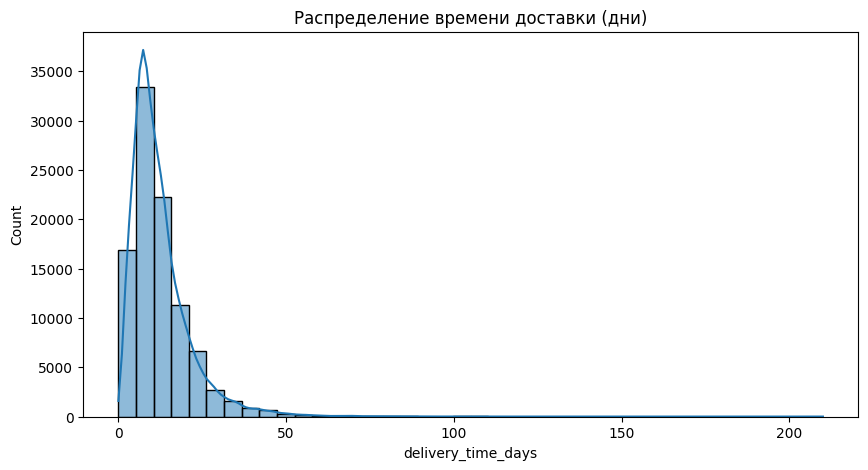

In [7]:
# Гистограмма
plt.figure(figsize=(10,5))
sns.histplot(df["delivery_time_days"], bins=40, kde=True)
plt.title("Распределение времени доставки (дни)")
plt.show()

Большинство заказов доставляются в пределах 5–20 дней, но имеется длинный хвост до 200+ дней.
Это означает, что встречаются редкие, но сильные задержки доставки, которые могут повлиять на модель и требуют обработки как выбросы.

In [8]:
# Проверка выбросов
df["delivery_time_days"].describe()

count    96970.000000
mean        12.477601
std          9.541197
min          0.000000
25%          7.000000
50%         10.000000
75%         16.000000
max        210.000000
Name: delivery_time_days, dtype: float64

Медиана составляет 10 дней, а максимум достигает 210 дней. Такое большое расстояние между 75-м перцентилем в 16 дней и максимумом говорит о наличии значительных выбросов

In [9]:
p99 = df["delivery_time_days"].quantile(0.99)
df = df[df["delivery_time_days"] <= p99]

потеря <=1% строк нормальна

In [10]:
df.shape

(96055, 14)

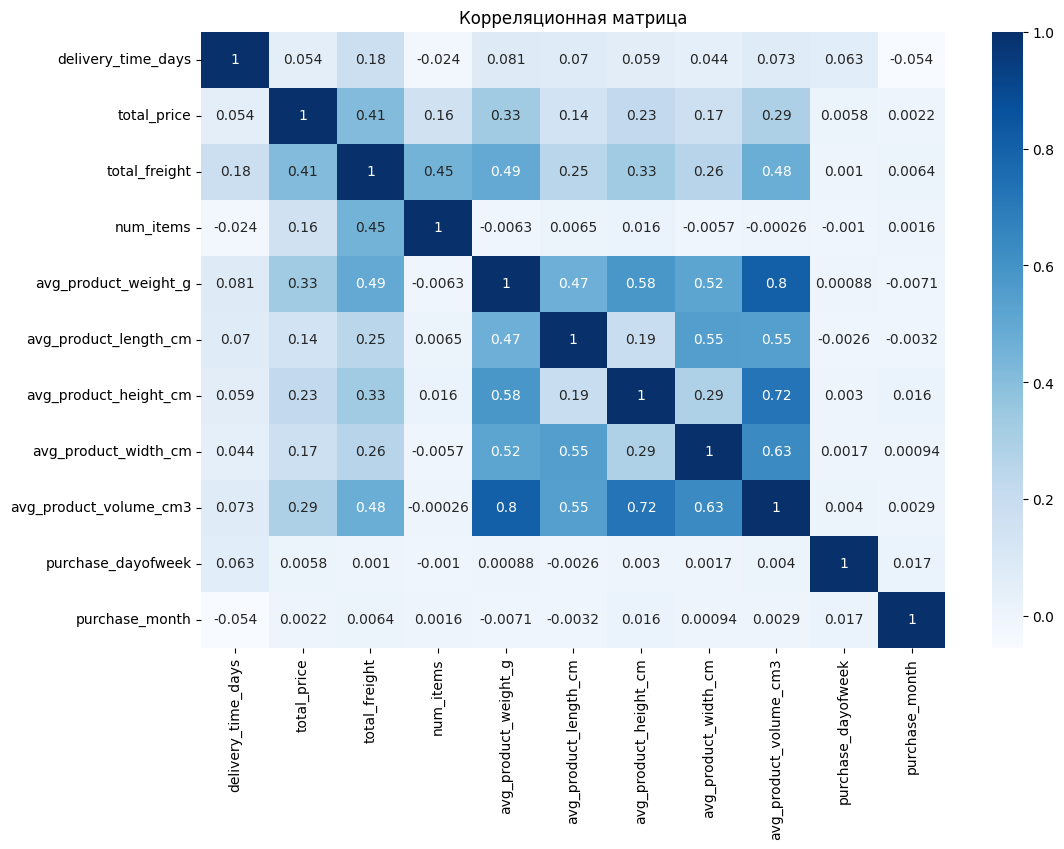

In [11]:
# Корреляции
numeric_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="Blues")
plt.title("Корреляционная матрица")
plt.show()

Целевая переменная почти не коррелирует ни с одним из признаков, так что сильные линейные связи отсутствуют.

При этом между товарными характеристиками наблюдается высокая взаимная корреляция, а между финансовыми признаками умеренная.

# Анализ категориальных признаков


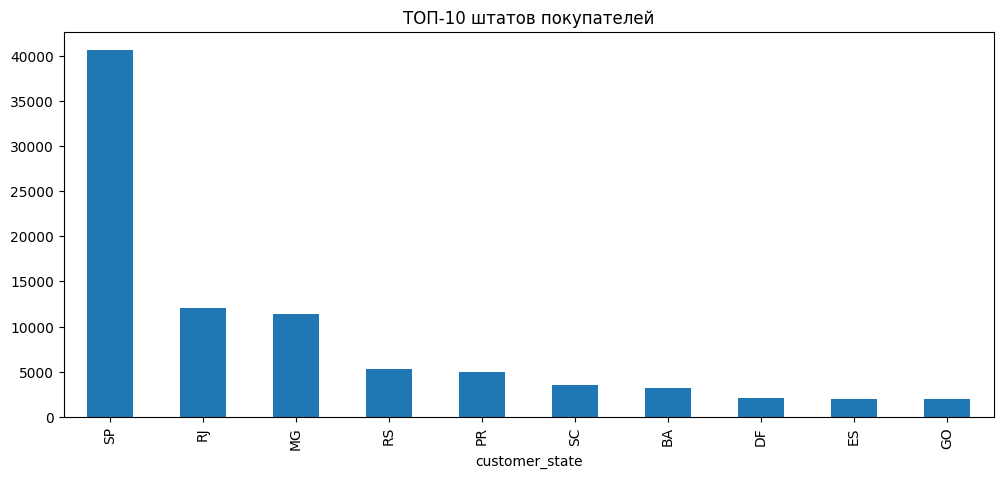

In [12]:
# Customer state
plt.figure(figsize=(12,5))
df["customer_state"].value_counts().head(10).plot(kind="bar")
plt.title("ТОП-10 штатов покупателей")
plt.show()

Большинство покупателей находятся в штате SP,

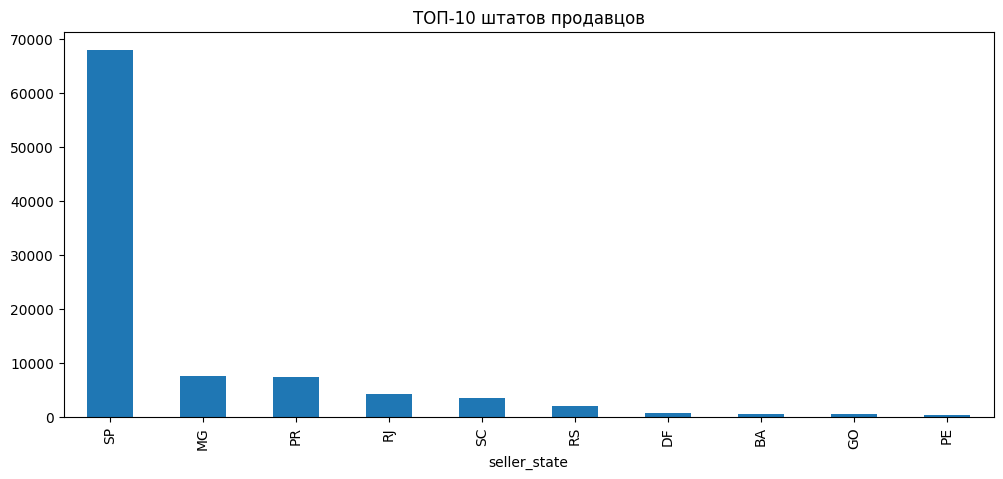

In [13]:
#Seller state
plt.figure(figsize=(12,5))
df["seller_state"].value_counts().head(10).plot(kind="bar")
plt.title("ТОП-10 штатов продавцов")
plt.show()

Большинство продавцов также сосредоточено в штате SP,

# Взаимосвязи признаков с target

In [14]:
# Корреляция с delivery_time_days
df[numeric_cols].corr()["delivery_time_days"].sort_values(ascending=False)

delivery_time_days        1.000000
total_freight             0.180608
avg_product_weight_g      0.081324
avg_product_volume_cm3    0.073121
avg_product_length_cm     0.070090
purchase_dayofweek        0.063456
avg_product_height_cm     0.059242
total_price               0.053749
avg_product_width_cm      0.044267
num_items                -0.023545
purchase_month           -0.053947
Name: delivery_time_days, dtype: float64

Ни один признак не показывает сильной линейной связи с временем доставки, наибольшая корреляция наблюдается у стоимости доставки ~0.18, но она всё равно слабая. 

Зависимость сложная и неленейная.

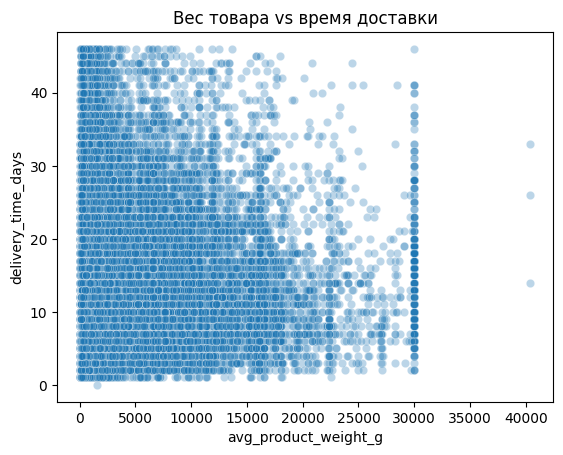

In [15]:
#Влияние веса товара
sns.scatterplot(
    data=df,
    x="avg_product_weight_g",
    y="delivery_time_days",
    alpha=0.3
)
plt.title("Вес товара vs время доставки")
plt.show()

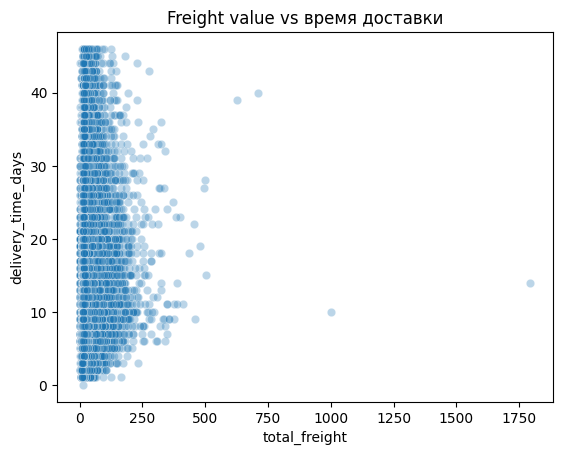

In [16]:
# Влияние freight_value
sns.scatterplot(
    data=df,
    x="total_freight",
    y="delivery_time_days",
    alpha=0.3
)
plt.title("Freight value vs время доставки")
plt.show()

# Вывод

Датасет содержит ~96 тыс. записей без значимых пропусков. 16 строк с отсутствующими характеристиками товара удалены. Время доставки имеет медиану 10 дней, но распределение скошено вправо, поэтому выбросы были обрезаны по 99-му перцентилю (утеря <1%). Корреляции с целевой переменной слабые, что указывает на нелинейный характер зависимости. Покупатели и продавцы сконцентрированы в штате SP. Данные очищены и готовы к моделированию, при этом предпочтительны нелинейные алгоритмы.

In [17]:
df.to_csv("../data/processed/ml_delivery_dataset_cleaned.csv", index=False)